In [1]:
# -------------------------------------------------------------
# Common pre‑amble – read config & export core variables
# -------------------------------------------------------------

from pathlib import Path
import os, sys

# infer repo root from the location of this file
repo_root = os.path.abspath('..')
sys.path.insert(0, str(repo_root))  # allow `import src.*`
from config.notebook_setup import *

Repository Root: /home/marcmaceira/projects/reuters-rag-classifier_clean_v2
Configuration: {'general': {'run_name': 'experiment_with_10_classes', 'seed': 42, 'n_classes': 10}, 'dataset': {'split_type': 'temporal', 'test_split': 0.2, 'cutoff_year': 1996}, 'paths': {'data_exploration_dir': 'output/experiment_with_10_classes/data_exploration', 'artifacts_dir': 'output/experiment_with_10_classes/artifacts', 'embeddings_dir': 'output/experiment_with_10_classes/embeddings', 'models_dir': 'output/experiment_with_10_classes/models', 'results_dir': 'output/experiment_with_10_classes/results'}, 'model': {'embedding_backend': 'sbert', 'sbert_model_name': 'sentence-transformers/all-MiniLM-L12-v2', 'openai_model_name': 'text-embedding-3-small', 'classifier': 'linear_svm', 'rag_top_k': 5, 'use_llm_refine': False}, 'training': {'batch_size': 32, 'max_epochs': 10, 'learning_rate': '1e-3'}, 'evaluation': {'metrics': ['accuracy', 'macro_f1', 'auc_ovr']}}

=== Configuration Variables ===

[DATASET]
  DAT

# Reuters News Topic Classification - Exploratory Data Analysis

This notebook performs detailed exploratory data analysis on the Reuters news topic classification dataset. We'll analyze various aspects of the data to better understand its characteristics and potential challenges.

## Setup and Data Loading

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.datasets.dataset import get_dataset
from src.exploration import class_frequency, length_distribution




In [3]:

# Load dataset
# X_train, y_train, _, _, _ = get_dataset(split_type="standard", n_classes=N_CLASSES)
X_train, y_train, X_test, y_test, classes = get_dataset(
    split_type=DATASET_SPLIT_TYPE,
    n_classes=N_CLASSES,
    cutoff_year=GENERAL_CUTOFF_YEAR
)

print(f"Loaded {len(X_train)} training documents with {N_CLASSES} classes")


INFO | Loading Reuters dataset with configuration:
INFO |   - Split type: temporal
INFO |   - Number of classes: 10
INFO |   - Cutoff year: 1996
INFO |   - Random seed: None
INFO | Loading temporal split with cutoff year 1996
INFO | Temporal split: 0 documents before 1996, 0 from 1996 onward
/home/marcmaceira/projects/reuters-rag-classifier_clean_v2/src/datasets/dataset.py:245: UserWarning: No test documents found in or after cutoff_year – falling back to default split.
  _warnings.warn("No test documents found in or after cutoff_year – falling back to default split.")
WARNING | No test documents found in or after 1996 - falling back to default split
INFO | Loading standard train/test split
INFO | Selected 10 classes: earn, acq, crude, interest, money-fx and more...
INFO | Dataset prepared with:
INFO |   - Training samples: 6337
INFO |   - Test samples: 2477
INFO |   - Classes: 10


Loaded 6337 training documents with 10 classes


## 1. Class Distribution Analysis

Let's analyze the distribution of topics in our dataset to understand class imbalance.

In [4]:
import os

# Plot length distribution
plt.figure(figsize=(10, 6))
stats = length_distribution(X_train, save_path=os.path.join(DATA_EXPLORATION_DIR, "document_length_distribution.png"))
print(f"Mean length: {stats['stats']['mean']:.1f} tokens, median: {stats['stats']['median']}")

# Calculate length percentiles
lengths = [len(doc.split()) for doc in X_train]
percentiles = np.percentile(lengths, [25, 50, 75, 90, 95, 99])
print("\nDocument Length Percentiles:")
length_stats = []
for p, percentile in zip([25, 50, 75, 90, 95, 99], percentiles):
    print(f"{p}th percentile: {percentile:.0f} tokens")
    length_stats.append({'percentile': p, 'length': int(percentile)})

# Save document length statistics to CSV
pd.DataFrame(length_stats).to_csv(os.path.join(DATA_EXPLORATION_DIR, "document_length_stats.csv"), index=False)

Mean length: 119.9 tokens, median: 77.0

Document Length Percentiles:
25th percentile: 40 tokens
50th percentile: 77 tokens
75th percentile: 142 tokens
90th percentile: 278 tokens
95th percentile: 404 tokens
99th percentile: 667 tokens


<Figure size 1000x600 with 0 Axes>

## 2. Document Length Analysis

Understanding the length distribution of articles helps us make decisions about preprocessing and model architecture.

In [5]:
# Plot length distribution
plt.figure(figsize=(10, 6))


from src.exploration import class_frequency, length_distribution
import pandas as pd

stats = length_distribution(X_train, save_path=os.path.join(DATA_EXPLORATION_DIR, "document_length_distribution.png"), output_dir=DATA_EXPLORATION_DIR)
print(f"Mean length: {stats['stats']['mean']:.1f} tokens, median: {stats['stats']['median']}")

# Access percentile information from the returned stats
percentile_stats = stats['percentile_stats']


Document Length Percentiles:
25th percentile: 40 tokens
50th percentile: 77 tokens
75th percentile: 142 tokens
90th percentile: 278 tokens
95th percentile: 404 tokens
99th percentile: 666 tokens
Mean length: 119.9 tokens, median: 77.0


<Figure size 1000x600 with 0 Axes>

## 3. Vocabulary Analysis

Let's examine the vocabulary characteristics of our dataset.

In [6]:
#!/usr/bin/env python
"""
Simple script to run comprehensive vocabulary analysis on Reuters data.
"""
from src.vocabulary_analysis import comprehensive_analysis


# Run comprehensive analysis with custom settings
analysis_results = comprehensive_analysis(
    texts=X_train,                                          # Your text documents
    labels=y_train,                                         # Class labels for class-specific analysis
    label_names=classes,                                # Names of the classes 
    output_dir=os.path.join(DATA_EXPLORATION_DIR),                    # Output directory for results
    min_word_length=3,                                      # Minimum word length (filters short tokens)
    top_n=50,                                               # Number of top words to analyze
    create_visualizations=True,                             # Create and save plots
    create_csv=True                                         # Save results to CSV files
)

# The analysis_results dictionary contains all the results:
# - analysis_results['basic'] - basic analysis (only stopwords removed)
# - analysis_results['standard'] - standard filtering (stopwords, numbers, financial terms)
# - analysis_results['advanced'] - advanced filtering (adds domain-specific stopwords)
# - analysis_results['basic_class'] - class-specific words with basic filtering
# - analysis_results['standard_class'] - class-specific words with standard filtering
# - analysis_results['advanced_class'] - class-specific words with advanced filtering

print("\nAnalysis complete! Results saved to the 'vocab_analysis_custom' directory.")
print("You can also access the results programmatically through the returned dictionary.")

# Example: Get the top 5 words after advanced filtering
print("\nTop 5 words (advanced filtering):")
for word, count in analysis_results['advanced']['word_counts'].most_common(5):
    print(f"  {word}: {count:,}")

# Example: Get the most distinctive word for each class
print("\nMost distinctive word by class (advanced filtering):")
for class_name in classes:
    if class_name in analysis_results['advanced_class'].columns:
        top_word = analysis_results['advanced_class'][class_name][0]
        if top_word:  # Check that it's not an empty string
            print(f"  {class_name}: {top_word}") 

Running comprehensive vocabulary analysis on 6337 documents...

======= BASIC FILTERING =======
Settings: Remove stopwords only
Total unique words (basic filtering): 23,018

Top 10 words (basic filtering):
  mln: 11,605
  vs: 9,234
  s: 8,693
  dlrs: 7,810
  lt: 6,003
  000: 5,930
  cts: 5,702
  1: 5,521
  pct: 4,703
  net: 4,460

======= STANDARD FILTERING =======
Settings: Remove stopwords, numbers, and financial terms
Total unique words (standard filtering): 21,206

Top 10 words (standard filtering):
  net: 4,460
  year: 4,348
  loss: 3,952
  company: 3,175
  would: 2,509
  bank: 2,497
  share: 2,255
  profit: 2,239
  oil: 1,939
  shares: 1,857

======= ADVANCED FILTERING =======
Settings: Remove stopwords, numbers, financial terms, and additional domain-specific stopwords
Total unique words (advanced filtering): 21,193

Top 10 words (advanced filtering):
  net: 4,460
  year: 4,348
  loss: 3,952
  company: 3,175
  bank: 2,497
  share: 2,255
  profit: 2,239
  oil: 1,939
  shares: 1,8

## 4. Topic Co-occurrence Analysis

Let's examine if there are any patterns in how topics appear together in articles.

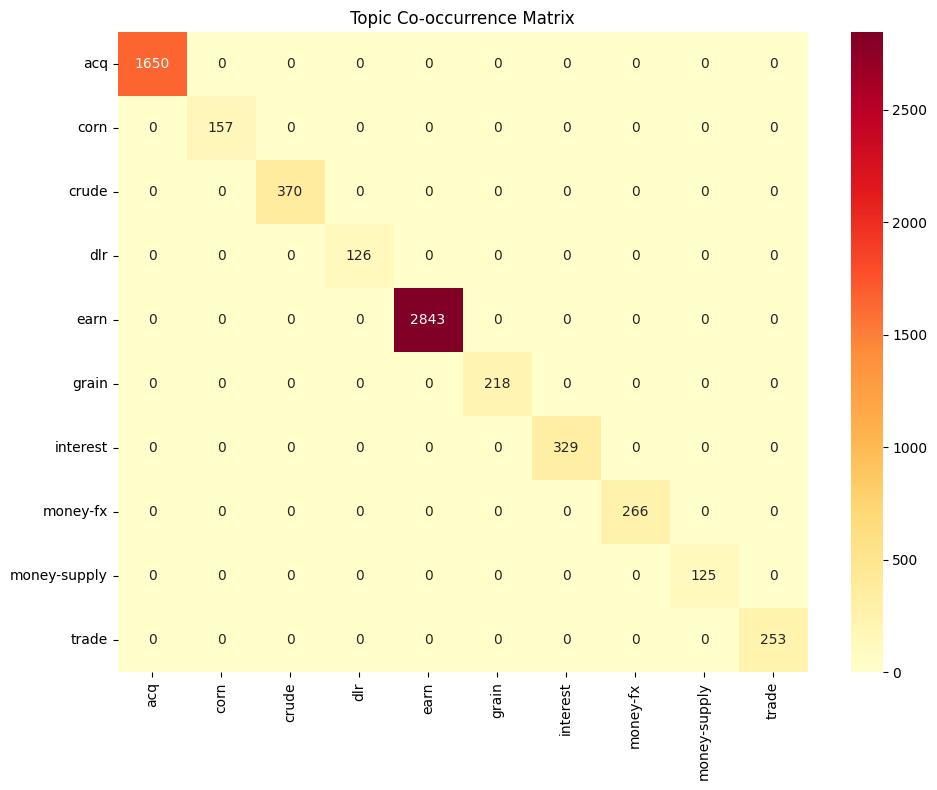

In [7]:
from src.exploration import topic_cooccurrence

# Call the helper function - it handles everything in one call
cooccurrence_df = topic_cooccurrence(
    y_train, 
    save_path=os.path.join(DATA_EXPLORATION_DIR, "topic_cooccurrence.png")
)

## Key Findings

1. **Class Imbalance**: The dataset shows significant class imbalance, with 'earn' and 'acq' being the dominant classes.

2. **Document Length**: Most articles are relatively short, with a median length of around 77 tokens. However, there's a long tail of longer articles.

3. **Vocabulary**: The dataset has a rich vocabulary, with many domain-specific financial terms.

4. **Topic Relationships**: Some topics show stronger co-occurrence patterns than others, which could be useful for multi-label classification.

## Next Steps

Based on this analysis, in the next notebook we'll:
1. Implement appropriate class balancing techniques
2. Design a preprocessing pipeline that handles the document length distribution
3. Create an effective vocabulary management strategy